In [25]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

In [26]:
# Cell 2: Data Loading and Preprocessing
def load_and_preprocess_data(filepath: str) -> tuple:
    """
    Load housing dataset and perform one-hot encoding.
    Target variable is log-transformed to handle right-skewness.
    """
    df = pd.read_csv(filepath)

    y_log = np.log(df['price'])
    X = df.drop('price', axis=1)

    cat_cols = [
        'mainroad', 'guestroom', 'basement', 'hotwaterheating',
        'airconditioning', 'prefarea', 'furnishingstatus'
    ]

    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    return X, y_log

X, y_log = load_and_preprocess_data('Housing.csv')

In [27]:
# Cell 3: Data Splitting and Scaling
def split_and_scale_data(X: pd.DataFrame, y_log: pd.Series) -> tuple:
    """
    Split data into 80% training and 20% testing sets.
    Apply standard scaling to features.
    """
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train_log, y_test_log

X_train_scaled, X_test_scaled, y_train_log, y_test_log = split_and_scale_data(X, y_log)

In [28]:
# Cell 4: XGBoost Model Training with GridSearchCV
def train_xgboost_model(X_train: np.ndarray, y_train: pd.Series, isBest: bool = True) -> GridSearchCV:
    """
    Perform hyperparameter tuning for XGBoost using GridSearchCV.
    """
    xgbr = XGBRegressor(random_state=42)

    if not isBest:
        params = {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.1],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0],
            'max_depth': [6, 8, 10],
            'gamma': [0.1, 0.3, 0.5],
        }
    else:
        params = {
            'n_estimators': [300],
            'learning_rate': [0.1],
            'subsample': [0.6],
            'colsample_bytree': [0.8],
            'max_depth': [8],
            'gamma': [0.1],
        }

    grid_search = GridSearchCV(
        estimator=xgbr,
        param_grid=params,
        cv=5,
        scoring='neg_mean_squared_error',
        return_train_score=True,
        verbose=1,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    return grid_search

grid_search = train_xgboost_model(X_train_scaled, y_train_log, isBest=True)
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.6}


In [29]:
# Cell 5: Model Evaluation
def evaluate_model(y_true_log: pd.Series, y_pred_log: np.ndarray) -> None:
    """
    Calculate and display RMSE, RRMSE, R-squared, and MAE.
    Values are inverse-transformed (exp) to reflect the original price scale.
    """
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rrmse = rmse / np.mean(y_true)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"RMSE: {rmse:,.2f}")
    print(f"RRMSE: {rrmse:.2f}")
    print(f"R^2: {r2:.2f}")
    print(f"MAE: {mae:,.2f}")

best_xgb = grid_search.best_estimator_
y_pred_log = best_xgb.predict(X_test_scaled)

evaluate_model(y_test_log, y_pred_log)

RMSE: 1,352,015.72
RRMSE: 0.27
R^2: 0.64
MAE: 976,624.56


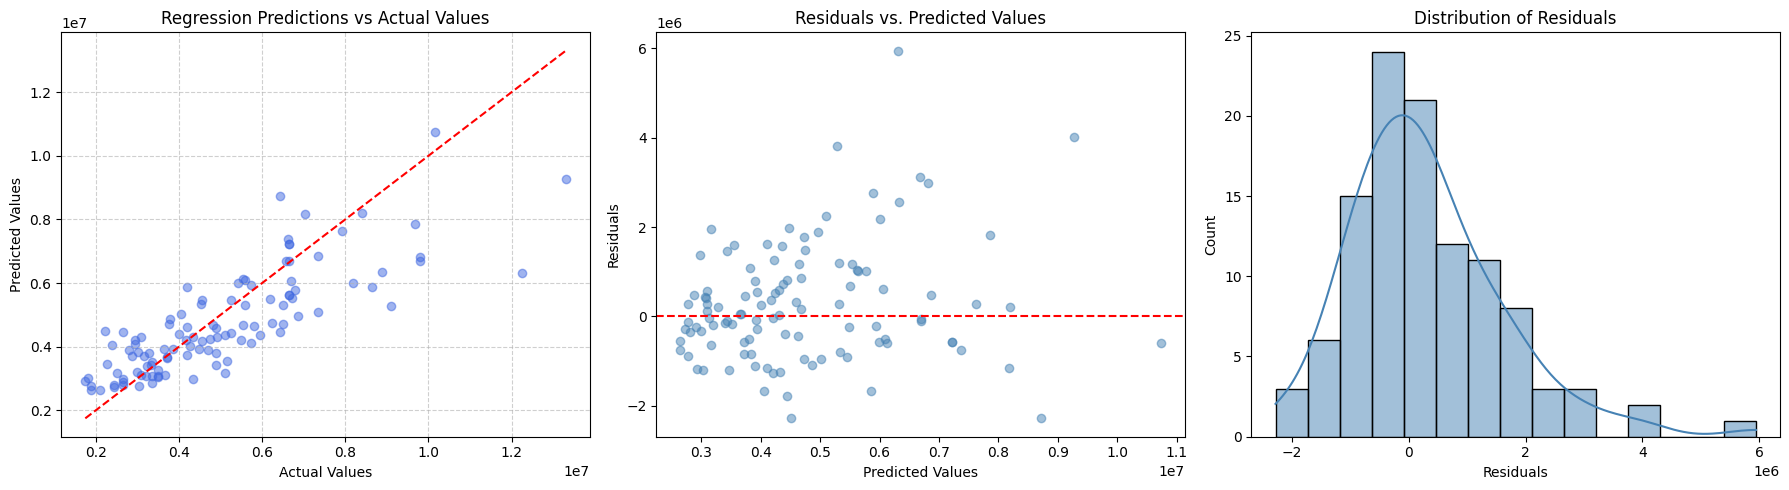

In [30]:
# Cell 6: Residuals and Predictions Visualization
def plot_evaluation_metrics(y_true_log: pd.Series, y_pred_log: np.ndarray) -> None:
    """
    Generate evaluation plots:
    1. Regression Predictions vs Actual Values
    2. Residuals vs. Predicted Values
    3. Distribution of Residuals
    """
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Predictions vs Actual Values
    axes[0].scatter(y_true, y_pred, alpha=0.5, color='royalblue')
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    axes[0].set_title('Regression Predictions vs Actual Values')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # 2. Residuals vs. Predicted Values
    axes[1].scatter(y_pred, residuals, alpha=0.5, color='steelblue')
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residuals vs. Predicted Values')

    # 3. Distribution of Residuals
    sns.histplot(residuals, kde=True, ax=axes[2], color='steelblue', bins=15)
    axes[2].set_xlabel('Residuals')
    axes[2].set_title('Distribution of Residuals')

    plt.tight_layout()
    plt.show()

plot_evaluation_metrics(y_test_log, y_pred_log)

In [31]:
# Cell 7: Import Random Forest and Train Model with GridSearchCV
from sklearn.ensemble import RandomForestRegressor

def train_random_forest_model(X_train: np.ndarray, y_train: pd.Series, isBest: bool = True) -> GridSearchCV:
    """
    Perform hyperparameter tuning for Random Forest using GridSearchCV.

    Args:
        X_train (np.ndarray): Scaled training features.
        y_train (pd.Series): Log-transformed training target.
        isBest (bool): Flag to toggle between full parameter grid search
                       or using the known best parameters.

    Returns:
        GridSearchCV: The fitted grid search model object.
    """
    rf = RandomForestRegressor(random_state=42)

    if not isBest:
        params = {
            'n_estimators': [80, 100, 200],
            'max_depth': [None, 8, 10, 20],
            'min_samples_split': [2, 4, 10],
            'min_samples_leaf': [1, 2, 4],
            'bootstrap': [True, False],
        }
    else:
        params = {
            'n_estimators': [80],
            'max_depth': [10],
            'min_samples_split': [10],
            'min_samples_leaf': [2],
            'bootstrap': [True],
        }

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=params,
        cv=5,
        scoring='neg_mean_squared_error',
        return_train_score=True,
        verbose=1,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    return grid_search

# Execute training pipeline for Random Forest
grid_search_rf = train_random_forest_model(X_train_scaled, y_train_log, isBest=True)
print(f"Best parameters: {grid_search_rf.best_params_}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 80}


In [32]:
# Cell 8: Random Forest Model Evaluation
# Retrieve the best estimator from the grid search
best_rf = grid_search_rf.best_estimator_

# Make predictions on the scaled test set
y_pred_log_rf = best_rf.predict(X_test_scaled)

# Calculate and display metrics using the previously defined function
print("--- Random Forest Evaluation Metrics ---")
evaluate_model(y_test_log, y_pred_log_rf)

--- Random Forest Evaluation Metrics ---
RMSE: 1,473,468.55
RRMSE: 0.29
R^2: 0.57
MAE: 1,061,768.15


--- Random Forest Evaluation Plots ---


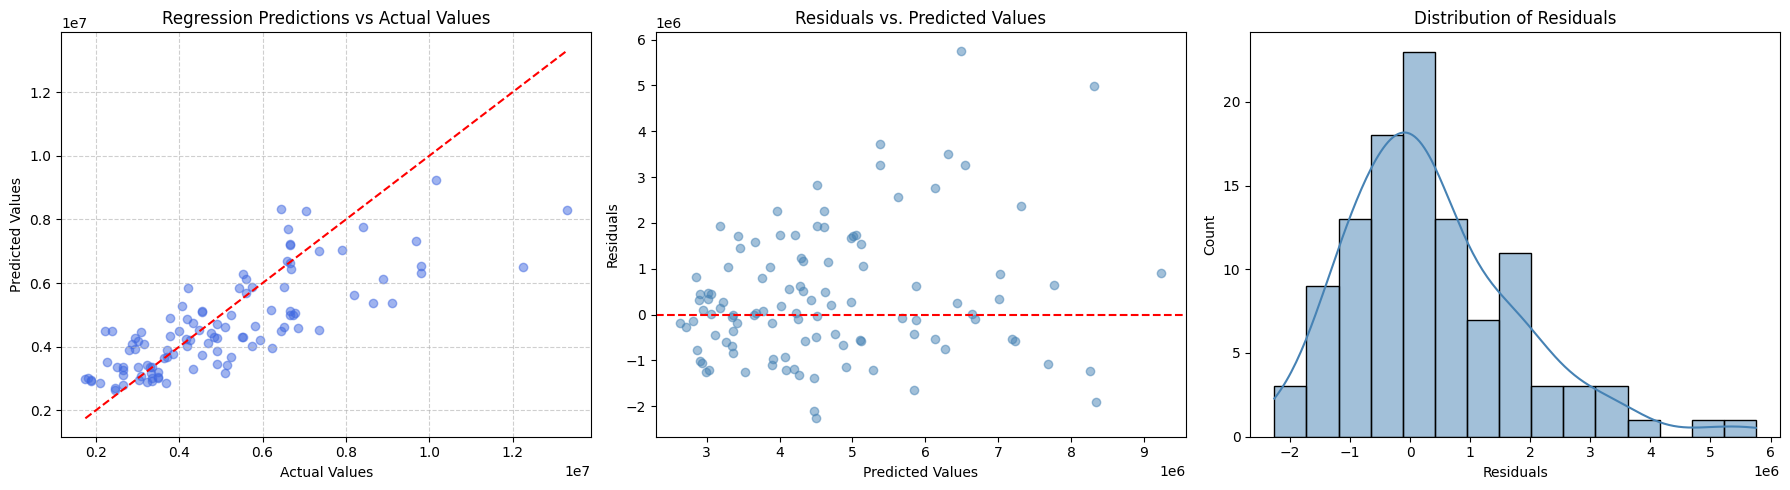

In [33]:
# Cell 9: Random Forest Residuals and Predictions Visualization
# Generate evaluation plots using the previously defined function
print("--- Random Forest Evaluation Plots ---")
plot_evaluation_metrics(y_test_log, y_pred_log_rf)